In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [20]:
df_train = pd.read_csv("../data_train_frequency.csv")
df_train.drop(columns=["Unnamed: 0"],inplace=True)
df_train

,1,2,3,4,5,6,7,8,9,10,...,204,205,206,207,208,209,210,211,212,213
0,0.0,10.0,950.000000,1074.0,274.986868,782.0,-0.319753,-1.432466,325.821586,1.000000,...,1.000000,172.000000,10.000000,9.000000,252.222222,10656.395062,87.777778,10339.061728,135.800000,4315.560000
1,0.0,17.0,574.500000,582.0,104.913059,378.0,0.158313,-0.696295,336.569414,1.000000,...,0.882353,-15.000000,15.000000,4.000000,158.000000,3944.000000,73.000000,6555.000000,-1.066667,697.528889
2,3.0,16.0,593.600000,594.0,4.687572,18.0,0.396421,-0.312612,94.909877,1.000000,...,1.000000,-4.000000,16.000000,15.000000,122.400000,2058.773333,12.533333,1360.782222,95.500000,68.750000
3,3.0,23.0,420.090909,420.0,3.591772,12.0,-0.021014,-0.856142,254.059787,0.826087,...,0.739130,-9.000000,6.000000,4.000000,40.666667,1120.888889,5.333333,1504.888889,12.000000,1464.000000
4,1.0,9.0,1068.750000,1075.0,25.118469,76.0,-0.276816,-1.271399,461.130814,1.000000,...,1.000000,2.000000,9.000000,8.000000,122.000000,671.000000,19.750000,569.437500,136.444444,43.358025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8511,3.0,16.0,615.733333,596.0,51.114860,152.0,2.153820,2.645687,365.256750,1.000000,...,0.003757,0.022262,0.003757,0.003757,0.044242,0.044242,0.043021,0.043021,0.037385,0.037385
8512,1.0,9.0,1091.500000,1093.0,5.894913,18.0,-0.311206,-1.184514,358.414529,1.000000,...,0.888889,-3.000000,9.000000,8.000000,81.428571,1294.530612,-40.000000,1746.285714,155.333333,4722.666667
8513,2.0,15.0,654.428571,648.0,107.653355,458.0,0.475616,0.784000,180.045117,1.000000,...,1.000000,-4.000000,15.000000,14.000000,77.142857,2213.551020,-1.714286,2686.204082,104.000000,3602.666667
8514,1.0,9.0,1075.000000,1083.0,24.535688,66.0,-0.263431,-1.567800,251.455499,1.000000,...,1.000000,14.000000,9.000000,8.000000,101.142857,4933.551020,-10.750000,7259.937500,88.222222,202.172840


In [21]:
x_train = df_train.iloc[:,1:].values
y_train = df_train.iloc[:,0].values

In [22]:
scale = MinMaxScaler()
x_train = scale.fit_transform(x_train)

In [23]:
pca = PCA(n_components=0.99)
x_train = pca.fit_transform(x_train)

In [24]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,...,128,129,130,131,132,133,134,135,136,137
0,-0.891936,-0.032942,0.997527,0.551870,0.010995,-0.175328,-0.170879,0.085335,0.030682,0.001926,...,-0.024669,-0.001677,0.008571,0.016581,0.027964,-0.011697,-0.015784,0.064779,0.004106,-0.081446
1,0.606074,0.318200,0.372033,-0.412667,0.124187,-0.174650,0.014257,-0.117637,-0.040576,0.078003,...,0.006296,-0.000869,0.011929,-0.018212,0.020800,-0.023293,0.004748,-0.015099,-0.006306,-0.021602
2,0.653068,0.584344,-0.239612,0.229274,-0.119470,-0.200605,0.164542,-0.142375,-0.018470,-0.143809,...,0.012197,-0.021066,-0.004068,0.004087,-0.009481,0.019966,0.012079,0.006859,0.002231,0.007086
3,1.701942,-1.151526,-0.003044,-0.348258,0.354323,0.274589,0.004660,0.415000,-0.285853,-0.477894,...,-0.006329,-0.048863,0.000306,-0.000822,-0.036747,0.002421,0.003472,0.045041,0.005910,0.075980
4,-0.842931,-0.110290,-0.157980,0.049439,-0.027736,0.000989,0.006721,0.055676,-0.024701,0.010895,...,0.026786,0.036254,-0.000521,-0.010169,0.057398,-0.047933,0.008176,-0.008553,-0.041460,-0.029952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8511,0.526630,-1.531304,0.102357,-0.228019,-0.630510,-0.451743,1.082999,0.148497,-0.534115,0.842481,...,-0.191308,0.004903,0.214498,0.367169,-0.133121,-0.129661,0.046782,0.260129,-0.194032,0.029091
8512,-0.877810,-0.123737,-0.296748,0.086264,-0.100449,0.169407,0.183920,0.189422,0.138274,-0.189176,...,0.033803,0.000456,0.052312,-0.018438,0.007966,-0.019451,0.008911,0.000281,0.022565,-0.016808
8513,0.401120,0.533847,0.153540,0.131141,-0.135051,0.137445,0.099278,-0.133793,-0.192339,-0.027020,...,-0.000638,0.019715,0.016457,-0.010717,0.001966,-0.004451,0.024614,0.005775,0.009682,-0.003981
8514,-0.858107,-0.124929,-0.307498,-0.018144,0.000190,0.037701,0.019901,-0.048731,-0.023686,-0.037784,...,0.006589,0.011870,0.002973,0.004305,-0.000895,0.010188,-0.017889,-0.003474,-0.004283,-0.011847


In [25]:
df_test = pd.read_csv("../data_test_frequency.csv")
df_test.drop(columns=["Unnamed: 0"],inplace=True)
df_test

,0,1,2,3,4,5,6,7,8,9,...,203,204,205,206,207,208,209,210,211,212
0,0.0,14.0,710.769231,628.0,153.204817,556.0,0.996355,0.207174,459.037295,1.000000,...,0.928571,-10.000000,10.0,9.0,146.000000,729.000000,78.250000,3140.437500,127.600000,1041.440000
1,0.0,10.0,968.666667,894.0,266.399867,932.0,0.979352,0.388359,398.464564,1.000000,...,0.600000,64.000000,7.0,7.0,140.500000,15314.750000,-27.000000,5249.000000,112.285714,8081.632653
2,0.0,11.0,797.000000,780.0,251.329664,794.0,0.260470,-1.002325,340.802438,1.000000,...,1.000000,26.000000,9.0,7.0,154.285714,1944.489796,18.571429,8070.530612,131.111111,1078.320988
3,2.0,13.0,757.500000,755.0,8.986100,26.0,0.048579,-1.449012,412.324324,1.000000,...,1.000000,-4.000000,12.0,12.0,108.500000,6122.750000,46.500000,7081.416667,121.833333,264.305556
4,0.0,23.0,413.909091,409.0,82.344017,426.0,3.023659,10.404884,168.041577,0.956522,...,0.083333,0.022262,11.0,12.0,0.044242,0.044242,-50.000000,0.000000,45.818182,832.330579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2125,1.0,9.0,1071.250000,1062.0,36.509417,118.0,1.263183,0.543003,364.303573,0.888889,...,0.777778,0.000000,9.0,8.0,342.857143,2843.265306,205.142857,11207.836735,96.000000,2281.142857
2126,1.0,8.0,1196.000000,1202.0,33.839959,102.0,-0.454057,-1.036905,181.876516,1.000000,...,1.000000,-26.000000,8.0,7.0,137.666667,228.555556,87.714286,14282.775510,169.142857,46.693878
2127,3.0,16.0,595.600000,590.0,23.734082,82.0,0.371174,-0.657132,137.696567,1.000000,...,1.000000,-8.000000,16.0,14.0,102.714286,1270.061224,7.285714,361.489796,90.400000,2186.240000
2128,1.0,8.0,1080.285714,996.0,180.470587,448.0,0.587475,-1.363827,561.988537,1.000000,...,1.000000,18.000000,8.0,5.0,62.400000,51.840000,-45.200000,0.960000,101.000000,5002.000000


In [26]:
x_test = df_test.iloc[:,1:].values
y_test = df_test.iloc[:,0].values

In [27]:
x_test = scale.transform(x_test)

In [28]:
x_test = pca.transform(x_test)

In [29]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
model = SVC()
# params = {
#     'kernel': ['rbf', 'sigmoid', 'poly', 'linear'],
#     'C': [0.01, 0.1, 1, 10, 100],
#     'gamma': ['scale', 'auto'],
#     'probability': [True]
# }
# {'C': 10, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}
# 0.948
# params = {
#     'kernel': ['rbf', 'sigmoid', 'poly', 'linear'],
#     'C': [5,10, 20],
#     'gamma': ['scale', 'auto'],
#     'probability': [True]
# }
# {'C': 20, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}
# 0.948
# params = {
#     'kernel': ['rbf'],
#     'C': [15, 20,22,28],
#     'gamma': ['scale', 'auto'],
#     'probability': [True]
# }
# {'C': 15, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}
# 0.949
params = {
    'kernel': ['rbf'],
    'C': [13,14,15, 16],
    'gamma': ['scale', 'auto'],
    'probability': [True]
}
grid_search = GridSearchCV(estimator=model, param_grid=params, cv=3, verbose=5, return_train_score=True,refit=True)
grid_model = grid_search.fit(x_train,y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3] END C=13, gamma=scale, kernel=rbf, probability=True;, score=(train=0.997, test=0.947) total time=   3.6s
[CV 2/3] END C=13, gamma=scale, kernel=rbf, probability=True;, score=(train=0.997, test=0.941) total time=   3.1s
[CV 3/3] END C=13, gamma=scale, kernel=rbf, probability=True;, score=(train=0.998, test=0.933) total time=   3.4s
[CV 1/3] END C=13, gamma=auto, kernel=rbf, probability=True;, score=(train=0.933, test=0.938) total time=   3.0s
[CV 2/3] END C=13, gamma=auto, kernel=rbf, probability=True;, score=(train=0.937, test=0.933) total time=   3.1s
[CV 3/3] END C=13, gamma=auto, kernel=rbf, probability=True;, score=(train=0.943, test=0.920) total time=   3.3s
[CV 1/3] END C=14, gamma=scale, kernel=rbf, probability=True;, score=(train=0.998, test=0.948) total time=   3.3s
[CV 2/3] END C=14, gamma=scale, kernel=rbf, probability=True;, score=(train=0.998, test=0.941) total time=   4.1s
[CV 3/3] END C=14, gamma=scale,

In [30]:
result_test = grid_model.predict(x_test)
result_train = grid_model.predict_proba(x_train)

In [31]:
pd.DataFrame(result_train).to_csv("./Result/proba_svm.csv")

In [32]:
grid_model.best_params_

{'C': 13, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}

In [33]:
grid_model.best_score_

0.9403466829968137

In [34]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,multilabel_confusion_matrix,f1_score,precision_score,accuracy_score,recall_score,precision_recall_fscore_support
def evaluation_test(y,y_pred):
    cm = confusion_matrix(y,y_pred)
    disp = ConfusionMatrixDisplay(cm,display_labels=['AFIB','SB','SR','GSVT'])
    disp.plot()
    plt.show()
    n_classes = len(cm)
    class_counts = np.sum(cm, axis=1)
    result = []
    specificities = []
    weights = class_counts / np.sum(class_counts) 
    for c in range(n_classes):
        tp = cm[c,c]
        fp = sum(cm[:,c]) - cm[c,c]
        fn = sum(cm[c,:]) - cm[c,c]
        tn = sum(np.delete(sum(cm)-cm[c,:],c))
        acc = (tp+tn) / (tp+fn+tn+fp)
        recall = tp/(tp+fn)
        precision = tp/(tp+fp)
        specificity = tn/(tn+fp)
        specificities.append(specificity)
        f1_score = 2*((precision*recall)/(precision+recall))
        if c+1 == 1:
            Rhythm = 'AFIB'
        elif c+1 == 2:
            Rhythm = 'SB'
        elif c+1 == 3:
            Rhythm = 'SR'
        else:
            Rhythm = 'GSVT'
        result.append([Rhythm,acc,recall,precision,f1_score,specificity])
    p_macro,r_macro,f_macro,support_macro = precision_recall_fscore_support(y,y_pred,average='macro')
    p_micro,r_micro,f_micro,support_micro = precision_recall_fscore_support(y,y_pred,average='micro')
    p_weighted,r_weighted,f_weighted,support_weighted = precision_recall_fscore_support(y,y_pred,average='weighted')

    s_marco = np.mean(specificities)
    tn_total = np.sum([np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1)) for i in range(n_classes)])
    fp_total = np.sum([np.sum(cm[:, i]) - cm[i, i] for i in range(n_classes)])
    s_mirco = tn_total / (tn_total + fp_total)
    s_weighted = np.sum(weights * specificities)

    result.append(['macro avg',None,f_macro,p_macro,r_macro,s_marco])
    result.append(['micro avg',None,f_micro,p_micro,r_micro,s_mirco])
    result.append(['weighted avg',None,f_weighted,p_weighted,r_weighted,s_weighted])
    return result
        

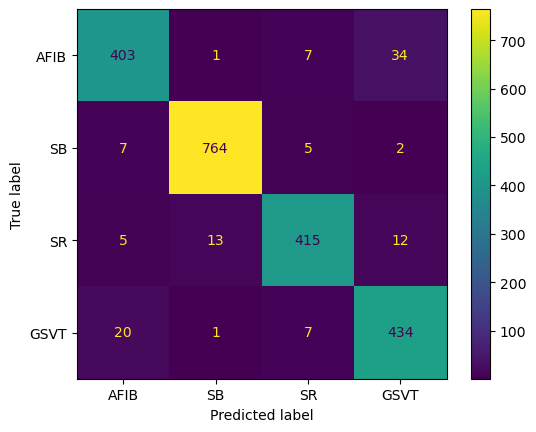

,Rhythm Group,ACC,F1-score,Precision,Recall,specificity
0,AFIB,0.965258,0.905618,0.926437,0.915909,0.981009
1,SB,0.986385,0.982005,0.980745,0.981374,0.988905
2,SR,0.976995,0.932584,0.956221,0.944255,0.988724
3,GSVT,0.964319,0.939394,0.900415,0.919492,0.971223
4,macro avg,NaN,0.940257,0.940954,0.939900,0.982465
5,micro avg,NaN,0.946479,0.946479,0.946479,0.982160
6,weighted avg,NaN,0.946520,0.946852,0.946479,0.983382


In [35]:
evaluation_test = evaluation_test(y_test,result_test)
df_evaluation_test = pd.DataFrame(data=evaluation_test,columns=["Rhythm Group","ACC","F1-score","Precision","Recall","specificity"])
df_evaluation_test

In [36]:
df_evaluation_test.to_csv("./Result/SVM_0_99.csv")